# Using LSTMS to predict Stock Prices

In [12]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense,LSTM,Dropout
import json

Let's first read the data. We are going to use pandas, and read the csv to make a data frame.

In [13]:
data = pd.read_csv('Google_train_data.csv')
data.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


Print out the basic information on our data frame.

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   object 
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   object 
 5   Volume  1258 non-null   object 
dtypes: float64(3), object(3)
memory usage: 59.1+ KB


In this example, we want to compare the strength of the LSTMS using different features. The different features in this example are going to be the different columns of the dataframe (close, open, high, etc.). But frst we need to convert the close column into a float type.

In [ ]:
data["Close"]=pd.to_numeric(data.Close,errors='coerce')
data = data.dropna()

We are going to make training data set for each of the features.

In [16]:
trainDataOpen = data.iloc[:,1:2].values
trainDataHigh = data.iloc[:,2:3].values
trainDataLow = data.iloc[:,3:4].values
trainDataClose = data.iloc[:,4:5].values


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1149 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1149 non-null   object 
 1   Open    1149 non-null   float64
 2   High    1149 non-null   float64
 3   Low     1149 non-null   float64
 4   Close   1149 non-null   float64
 5   Volume  1149 non-null   object 
dtypes: float64(4), object(2)
memory usage: 62.8+ KB


Then we will apply a MinMax scaler to all of features.

In [18]:
# Initialize separate scalers for each feature
sc_open = MinMaxScaler(feature_range=(0,1))
sc_high = MinMaxScaler(feature_range=(0,1))
sc_low = MinMaxScaler(feature_range=(0,1))
sc_close = MinMaxScaler(feature_range=(0,1))

trainDataOpen = sc_open.fit_transform(trainDataOpen)
trainDataHigh = sc_high.fit_transform(trainDataHigh)
trainDataLow = sc_low.fit_transform(trainDataLow)
trainDataClose = sc_close.fit_transform(trainDataClose)

We will then split the training data, using 60 data points as a timestep. Remember we must do this for all the features indiviually (is there a faster way?)

In [19]:
X_train_Open = []
y_train_Open = []
X_train_Close = []
y_train_Close = []
X_train_High = []
y_train_High = []
X_train_Low = []
y_train_Low = []

for i in range(60, 1149):  # 60 : timestep // 1149 : length of the data
    X_train_Open.append(trainDataOpen[i-60:i, 0])
    y_train_Open.append(trainDataOpen[i, 0])
    
    X_train_Close.append(trainDataClose[i-60:i, 0])
    y_train_Close.append(trainDataClose[i, 0])
    
    X_train_High.append(trainDataHigh[i-60:i, 0])
    y_train_High.append(trainDataHigh[i, 0])
    
    X_train_Low.append(trainDataLow[i-60:i, 0])
    y_train_Low.append(trainDataLow[i, 0])

# Convert lists to numpy arrays
X_train_Open, y_train_Open = np.array(X_train_Open), np.array(y_train_Open)
X_train_Close, y_train_Close = np.array(X_train_Close), np.array(y_train_Close)
X_train_High, y_train_High = np.array(X_train_High), np.array(y_train_High)
X_train_Low, y_train_Low = np.array(X_train_Low), np.array(y_train_Low)

Doing the necessary reshaping. The batch size indicates how many features are included in that data set. In our case it is one.

In [20]:
X_train_Open = np.reshape(X_train_Open,(X_train_Open.shape[0],X_train_Open.shape[1],1)) #adding the batch_size axis
X_train_Close = np.reshape(X_train_Close,(X_train_Close.shape[0],X_train_Close.shape[1],1)) #adding the batch_size axis
X_train_High = np.reshape(X_train_High,(X_train_High.shape[0],X_train_High.shape[1],1)) #adding the batch_size axis
X_train_Low = np.reshape(X_train_Low,(X_train_Low.shape[0],X_train_Low.shape[1],1)) #adding the batch_size axis


Single feature LSTM Model that we will apply to each feature individually!

I created a function to create and train the model.

In [21]:
def create_and_train_model(X_train, y_train, epochs=20, batch_size=32, features = 1, dropout = 0.4, units = 100):
    # Define the model architecture
    model = Sequential()
    model.add(LSTM(units=units, return_sequences=False, input_shape=(X_train.shape[1], features)))
    model.add(Dropout(dropout))
    model.add(Dense(units=features))
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=2)

    return model, history

In [22]:
# Define the datasets
datasets = {
    "Open": (X_train_Open, y_train_Open),
    "Close": (X_train_Close, y_train_Close),
    "High": (X_train_High, y_train_High),
    "Low": (X_train_Low, y_train_Low),
}

# Store models and histories
models = {}
hists = {}

for key, (X_train, y_train) in datasets.items():
    print(f"Training model for {key}...")
    model, history = create_and_train_model(X_train, y_train)
    models[key] = model
    hists[key] = history

Training model for Open...
Epoch 1/20


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 - 2s - 48ms/step - loss: 0.0907
Epoch 2/20
35/35 - 1s - 23ms/step - loss: 0.0097
Epoch 3/20
35/35 - 1s - 21ms/step - loss: 0.0065
Epoch 4/20
35/35 - 1s - 22ms/step - loss: 0.0061
Epoch 5/20
35/35 - 1s - 23ms/step - loss: 0.0050
Epoch 6/20
35/35 - 1s - 22ms/step - loss: 0.0050
Epoch 7/20
35/35 - 1s - 22ms/step - loss: 0.0044
Epoch 8/20
35/35 - 1s - 22ms/step - loss: 0.0054
Epoch 9/20
35/35 - 1s - 22ms/step - loss: 0.0047
Epoch 10/20
35/35 - 1s - 22ms/step - loss: 0.0040
Epoch 11/20
35/35 - 1s - 22ms/step - loss: 0.0036
Epoch 12/20
35/35 - 1s - 30ms/step - loss: 0.0039
Epoch 13/20
35/35 - 1s - 23ms/step - loss: 0.0041
Epoch 14/20
35/35 - 1s - 22ms/step - loss: 0.0037
Epoch 15/20
35/35 - 1s - 23ms/step - loss: 0.0034
Epoch 16/20
35/35 - 1s - 25ms/step - loss: 0.0035
Epoch 17/20
35/35 - 1s - 24ms/step - loss: 0.0038
Epoch 18/20
35/35 - 1s - 22ms/step - loss: 0.0040
Epoch 19/20
35/35 - 1s - 22ms/step - loss: 0.0034
Epoch 20/20
35/35 - 1s - 22ms/step - loss: 0.0035
Training model for C

Now we can plot the loss function as a graph and see how well each one performed.

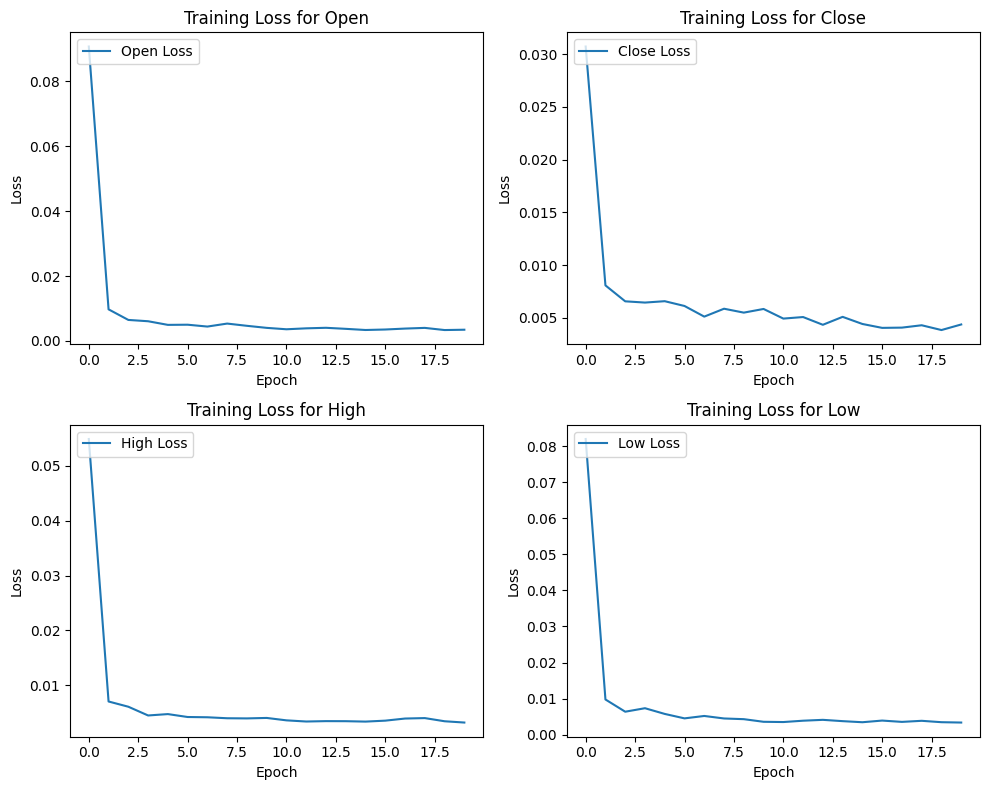

In [23]:
# Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # 2 rows, 2 columns
axes = axes.flatten()  # Flatten to iterate over axes easily

# Plot each model's loss in a subplot
for i, (model_name, history) in enumerate(hists.items()):
    ax = axes[i]
    ax.plot(history.history['loss'], label=f'{model_name} Loss')
    ax.set_title(f'Training Loss for {model_name}')
    ax.set_ylabel('Loss')
    ax.set_xlabel('Epoch')
    ax.legend(loc='upper left')

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


In this section of the code, we are going to use the trained model to predict the outputs.

In [25]:
testData = pd.read_csv('Google_test_data.csv')
testData["Close"]=pd.to_numeric(testData.Close,errors='coerce')
testData = testData.dropna()

# Extract the relevant columns as NumPy arrays
testDataOpen = testData.iloc[:, 1:2].values
y_test_open = testDataOpen[60:,0:]
testDataHigh = testData.iloc[:, 2:3].values
y_test_high = testDataHigh[60:,0:]
testDataLow = testData.iloc[:, 3:4].values
y_test_low = testDataLow[60:,0:]
testDataClose = testData.iloc[:, 4:5].values
y_test_close = testDataClose[60:,0:]


# Function to preprocess the data for a given column
def preprocess_column(column_data, scaler, timestep=60):
    # Scale the data using the provided scaler
    column_scaled = scaler.transform(column_data)
    # Prepare the input array for the model
    X_column = []
    length = len(column_data)
    for i in range(timestep, length):
        X_column.append(column_scaled[i - timestep:i, 0])
    X_column = np.array(X_column)
    X_column = np.reshape(X_column, (X_column.shape[0], X_column.shape[1], 1))  # Reshape for LSTM
    return X_column

# Use the preprocessing function for each column
X_test_Open = preprocess_column(testDataOpen, sc_open)
X_test_High = preprocess_column(testDataHigh, sc_high)
X_test_Low = preprocess_column(testDataLow, sc_low)
X_test_Close = preprocess_column(testDataClose, sc_close)

# Check shapes of processed test data
print("Shapes of processed test data:")
print("Open:", X_test_Open.shape)
print("High:", X_test_High.shape)
print("Low:", X_test_Low.shape)
print("Close:", X_test_Close.shape)

Shapes of processed test data:
Open: (192, 60, 1)
High: (192, 60, 1)
Low: (192, 60, 1)
Close: (192, 60, 1)


The prediciting:

In [26]:
y_pred_open = models["Open"].predict(X_test_Open)
y_pred_close = models["Close"].predict(X_test_Close)
y_pred_low = models["Low"].predict(X_test_Low)
y_pred_high = models["High"].predict(X_test_High)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  


Undo the scaling we did earlier.

In [27]:
# predicted_price = sc.inverse_transform(y_pred)

predicted_price_open = sc_open.inverse_transform(y_pred_open)
predicted_price_low = sc_low.inverse_transform(y_pred_low)
predicted_price_close = sc_close.inverse_transform(y_pred_close)
predicted_price_high = sc_high.inverse_transform(y_pred_high)

Plot the graphs.

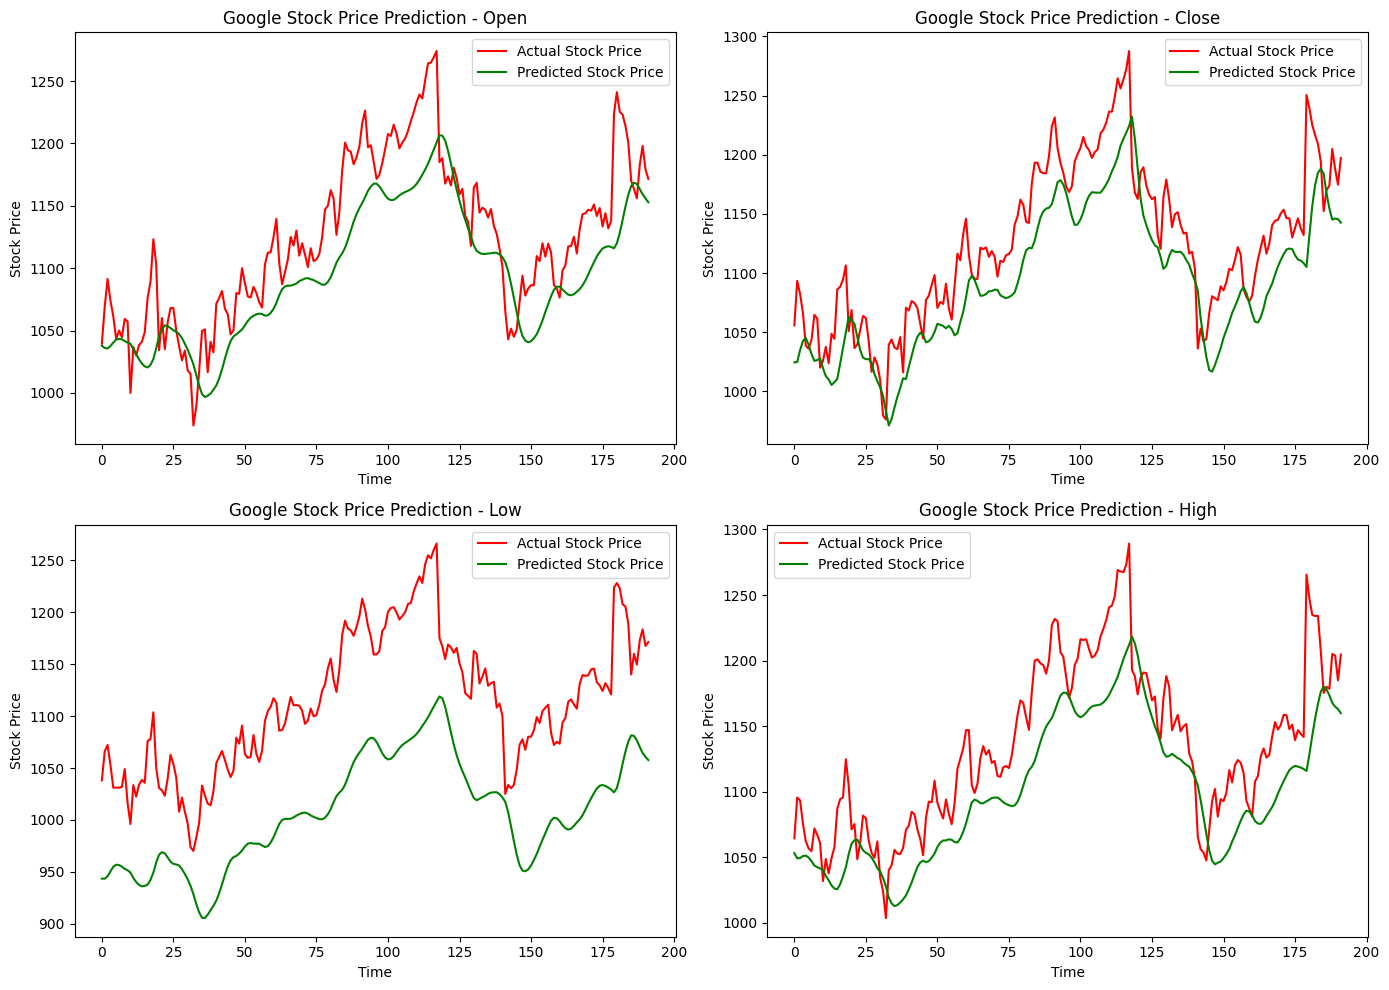

In [28]:
# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot for Open Prices
axes[0, 0].plot(y_test_open, color='red', label='Actual Stock Price')
axes[0, 0].plot(predicted_price_open, color='green', label='Predicted Stock Price')
axes[0, 0].set_title('Google Stock Price Prediction - Open')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Stock Price')
axes[0, 0].legend()

# Plot for Close Prices
axes[0, 1].plot(y_test_close, color='red', label='Actual Stock Price')
axes[0, 1].plot(predicted_price_close, color='green', label='Predicted Stock Price')
axes[0, 1].set_title('Google Stock Price Prediction - Close')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('Stock Price')
axes[0, 1].legend()

# Plot for Low Prices
axes[1, 0].plot(y_test_low, color='red', label='Actual Stock Price')
axes[1, 0].plot(predicted_price_low, color='green', label='Predicted Stock Price')
axes[1, 0].set_title('Google Stock Price Prediction - Low')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Stock Price')
axes[1, 0].legend()

# Plot for High Prices
axes[1, 1].plot(y_test_high, color='red', label='Actual Stock Price')
axes[1, 1].plot(predicted_price_high, color='green', label='Predicted Stock Price')
axes[1, 1].set_title('Google Stock Price Prediction - High')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Stock Price')
axes[1, 1].legend()

# Adjust layout for better spacing
plt.tight_layout()

# Display the plots
plt.show()

What can this tell us about the performance? Looking at the graphs doesn't show us anything glarling: all the features seem equally predictable.

Maybe we can make a function to get the mean squared error?

In [29]:
from sklearn.metrics import mean_squared_error

print("Open:")
print(mean_squared_error(y_test_open, predicted_price_open))

print("Low:")
print(mean_squared_error(y_test_low, predicted_price_low))

print("High:")
print(mean_squared_error(y_test_high, predicted_price_high))

print("Close:")
print(mean_squared_error(y_test_close, predicted_price_close))


Open:
1778.5397873786108
Low:
12182.570725705931
High:
1911.550823517967
Close:
1727.4360267315233
